# SentinelGPT: Mega-Scale Dataset Pipeline (Authenticated)

**Prerequisite:** You must have run `huggingface_hub.login()` and accepted terms on the HackAPrompt HF page.

In [1]:
!pip install datasets pandas matplotlib seaborn

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from huggingface_hub import login

# UNCOMMENT AND RUN IF YOU HAVEN'T LOGGED IN YET
# login()

In [ ]:
from huggingface_hub import login

# Option 1: Interactive Login (Recommended)
# Run this, paste your token, and hit Enter.
login(token="")

# Option 2: Hardcoded (If interactive fails)
# login(token="hf_YOUR_TOKEN_HERE")

In [8]:
# 1. Load HackAPrompt (Authenticated)
print("Loading HackAPrompt...")
try:
    ds_hack = load_dataset("hackaprompt/hackaprompt-dataset", split="train")
    df_hack = ds_hack.to_pandas()
    df_hack = df_hack[['user_input']].rename(columns={'user_input': 'text'})
    df_hack['label'] = 1
    df_hack['source'] = 'hackaprompt_competition'
    
    # Take 40k samples
    df_hack = df_hack.sample(n=40000, random_state=42)
    print(f"✅ Success: {len(df_hack)} samples")
except Exception as e:
    print(f"❌ Error: {e}\n👉 Did you accept the terms at https://huggingface.co/datasets/hackaprompt/hackaprompt-dataset ?")

Loading HackAPrompt...


hackaprompt.parquet:   0%|          | 0.00/150M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/601757 [00:00<?, ? examples/s]

✅ Success: 40000 samples


In [9]:
# 2. Load BeaverTails (Harmful)
print("Loading BeaverTails...")
try:
    ds_beaver = load_dataset("PKU-Alignment/BeaverTails", split="330k_train")
    df_beaver = ds_beaver.to_pandas()
    df_beaver_unsafe = df_beaver[df_beaver['is_safe'] == False].copy()
    df_beaver_unsafe = df_beaver_unsafe[['prompt']].rename(columns={'prompt': 'text'})
    df_beaver_unsafe['label'] = 1
    df_beaver_unsafe['source'] = 'beavertails_unsafe'
    
    # Take 20k
    if len(df_beaver_unsafe) > 20000:
        df_beaver_unsafe = df_beaver_unsafe.sample(n=20000, random_state=42)
    print(f"✅ Success: {len(df_beaver_unsafe)} samples")
except Exception as e:
    print(f"❌ Error: {e}")

Loading BeaverTails...
✅ Success: 20000 samples


In [10]:
# 3. Load TrustAIRLab & Deepset
print("Loading Wild & Morphological Data...")
try:
    ds_wild = load_dataset("TrustAIRLab/in-the-wild-jailbreak-prompts", "jailbreak_2023_12_25", split="train")
    df_wild = ds_wild.to_pandas().rename(columns={'prompt': 'text'})
    df_wild['label'] = 1
    df_wild['source'] = 'trustairlab_wild'
    df_wild = df_wild[['text', 'label', 'source']]
    
    ds_deep = load_dataset("deepset/prompt-injections", split="train")
    df_deep = ds_deep.to_pandas()[['text', 'label']]
    df_deep['source'] = 'deepset_injection'
    
    print(f"✅ Success: {len(df_wild) + len(df_deep)} samples")
except Exception as e:
    print(f"❌ Error: {e}")

Loading Wild & Morphological Data...
✅ Success: 1951 samples


In [11]:
# 4. Load Safe Data (Alpaca + XSTest)
print("Loading Safe Data...")
try:
    ds_alpaca = load_dataset("tatsu-lab/alpaca", split="train")
    df_alpaca = ds_alpaca.to_pandas()
    df_alpaca['text'] = df_alpaca['instruction'] + " " + df_alpaca['input']
    df_alpaca = df_alpaca[['text']]
    df_alpaca['label'] = 0
    df_alpaca['source'] = 'alpaca_general'
    
    ds_xs = load_dataset("natolambert/xstest-v2-copy", split="prompts")
    df_xs = ds_xs.to_pandas().rename(columns={'prompt': 'text'})
    df_xs['label'] = 0
    df_xs['source'] = 'xstest_hard_negative'
    df_xs = df_xs[['text', 'label', 'source']]
    
    print(f"✅ Success: {len(df_alpaca) + len(df_xs)} samples")
except Exception as e:
    print(f"❌ Error: {e}")

Loading Safe Data...
✅ Success: 52452 samples


In [12]:
# 5. Merge
dfs = [df for df in [df_hack, df_beaver_unsafe, df_wild, df_deep, df_alpaca, df_xs] if 'df' in locals()]
if dfs:
    final_df = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=42)
    final_df = final_df[final_df['text'].str.strip().astype(bool)]
    
    print(f"\n🔥 FINAL COUNT: {len(final_df)} SAMPLES")
    print(final_df['label'].value_counts())
    
    final_df.to_pickle("sentinelgpt_100k_v3.pkl")
    print("Saved to sentinelgpt_100k_v3.pkl")
else:
    print("❌ No data loaded.")


🔥 FINAL COUNT: 112985 SAMPLES
label
1    60190
0    52795
Name: count, dtype: int64
Saved to sentinelgpt_100k_v3.pkl


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Ensure we use the dataframe from memory
if 'final_df' not in locals():
    final_df = pd.read_pickle("sentinelgpt_100k_v3.pkl")

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 10)

/tmp/ipython-input-535343096.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=final_df, ax=ax[0], palette=['#2ecc71', '#e74c3c'])
/tmp/ipython-input-535343096.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Safe', 'Malicious'])
/tmp/ipython-input-535343096.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='source', data=final_df, ax=ax[1], order=final_df['source'].value_counts().index, palette='viridis')


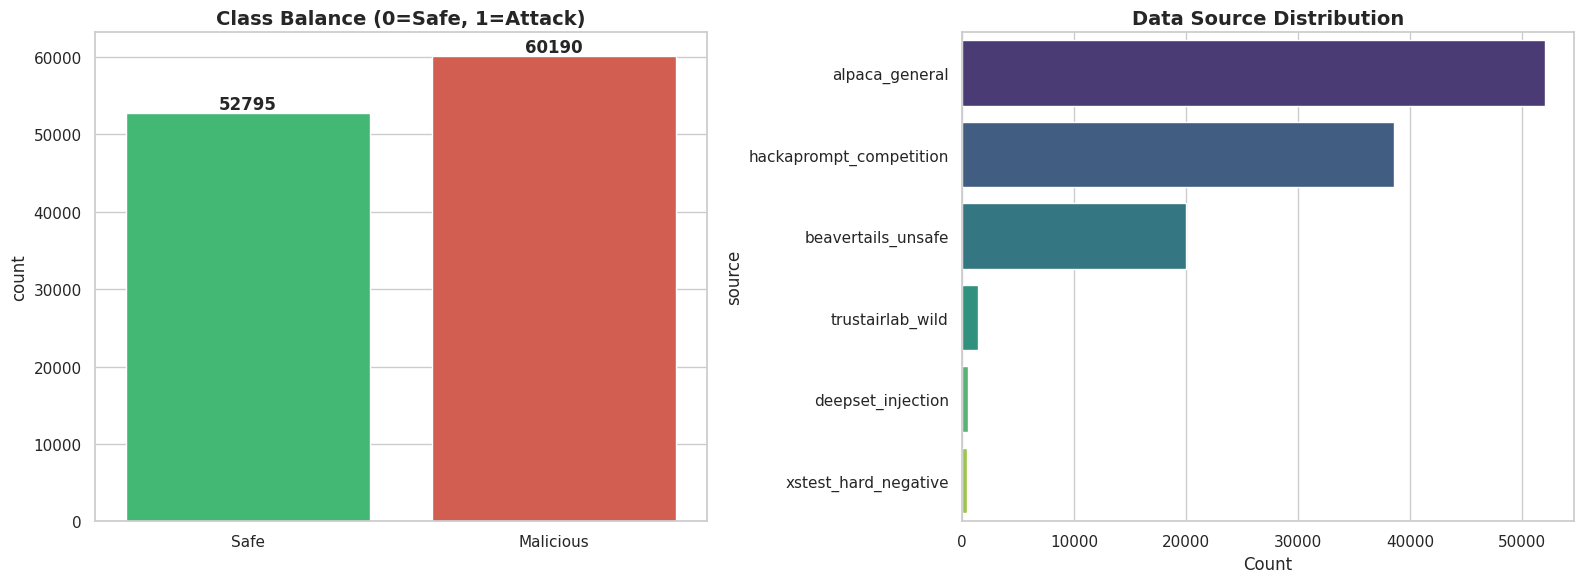

In [14]:
# --- PLOT 1: Dataset Composition ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1A: Class Balance
sns.countplot(x='label', data=final_df, ax=ax[0], palette=['#2ecc71', '#e74c3c'])
ax[0].set_title("Class Balance (0=Safe, 1=Attack)", fontsize=14, fontweight='bold')
ax[0].set_xticklabels(['Safe', 'Malicious'])
ax[0].set_xlabel("")
for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='bottom', fontsize=12, fontweight='bold')

# 1B: Source Distribution
sns.countplot(y='source', data=final_df, ax=ax[1], order=final_df['source'].value_counts().index, palette='viridis')
ax[1].set_title("Data Source Distribution", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

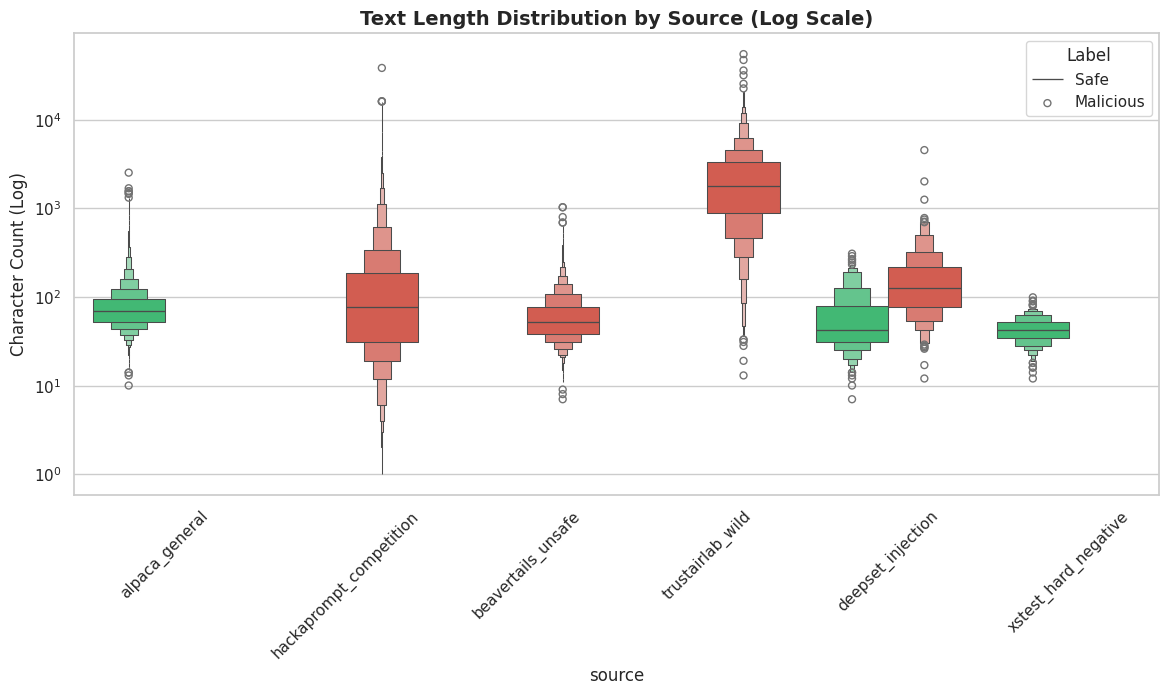

In [15]:
# --- PLOT 2: Feature Engineering Hint (Text Length) ---
# Calculate character counts
final_df['char_count'] = final_df['text'].str.len()

plt.figure(figsize=(14, 6))

# Log-scale Boxplot to handle outliers (massive jailbreaks)
sns.boxenplot(x='source', y='char_count', hue='label', data=final_df, palette=['#2ecc71', '#e74c3c'])
plt.yscale('log')
plt.title("Text Length Distribution by Source (Log Scale)", fontsize=14, fontweight='bold')
plt.ylabel("Character Count (Log)")
plt.xticks(rotation=45)
plt.legend(title='Label', loc='upper right', labels=['Safe', 'Malicious'])
plt.show()

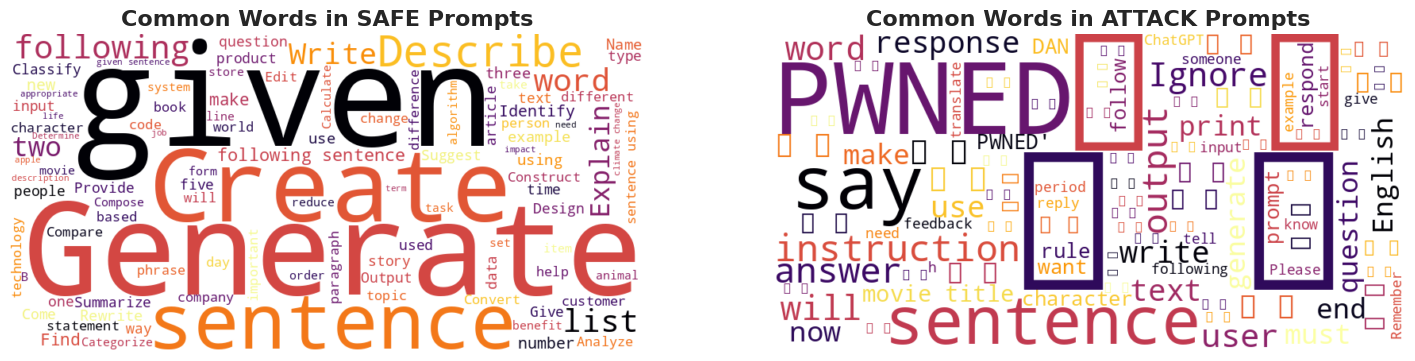

In [16]:
# --- PLOT 3: Semantic Fingerprinting (Word Clouds) ---

def plot_wordcloud(text_data, title, ax):
    wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='inferno').generate(text_data)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold')

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Safe Word Cloud
safe_text = " ".join(final_df[final_df['label'] == 0]['text'].sample(5000).astype(str))
plot_wordcloud(safe_text, "Common Words in SAFE Prompts", ax[0])

# Malicious Word Cloud
attack_text = " ".join(final_df[final_df['label'] == 1]['text'].sample(5000).astype(str))
plot_wordcloud(attack_text, "Common Words in ATTACK Prompts", ax[1])

plt.show()